In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Load All Images and there Labels

In [2]:
def load_images( data_dir , target_size=(200 , 200) ):

    images = []
    labels = []

    class_names = os.listdir(data_dir)

    for class_name in class_names:

        class_dir = os.path.join(data_dir , class_name)

        for image_name in os.listdir(class_dir):

            image_path = os.path.join(class_dir , image_name)
            
            try:

                image = Image.open(image_path)
                image = image.resize(target_size).convert("L")
                image_array = np.array(image).flatten()/255.0

                images.append(image_array)
                labels.append(class_name)

            except Exception as e:

                print(f"Error loading image {image_path} : {e}")

                continue

    return np.array(images) , np.array(labels)

In [3]:
dataset_path = r"dataset"
images , labels = load_images(dataset_path)

In [4]:
print(f"Image Data Shape: {images.shape} , Labels Shape : {labels.shape}")

Image Data Shape: (1000, 40000) , Labels Shape : (1000,)


## Split Datapoints in Train-Test Set

In [5]:
from sklearn.model_selection import train_test_split

train_images , test_images , train_labels , test_labels = train_test_split(
    images , labels , test_size = 0.2 , random_state=42 
)

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_labels = label_encoder.fit_transform(train_labels)
test_labels = label_encoder.transform(test_labels)

In [7]:
import random
def augment_data(images , labels , augmentation_factor=2):

    augmented_images = []
    augmented_labels = []

    for image , label in zip(images , labels):
        augmented_images.append(image)
        augmented_labels.append(label)

        for _ in range(augmentation_factor):
            # decide angle of rotation
            angle = random.uniform(-30 , 30)
            img = Image.fromarray( ( image.reshape( (200,200) ) * 255).astype(np.uint8) )

            # rotate image
            img = img.rotate(angle)
            rotated_image = np.array(img).flatten()/255.0

            # add rotated image
            augmented_images.append(rotated_image)
            
            augmented_labels.append(label)
    
    return np.array(augmented_images) , np.array(augmented_labels)

In [ ]:
x_train_augmented , y_train_augmented = augment_data( train_images , train_labels )

In [9]:
print(f"Training Data: Features-> \n{x_train_augmented} \n\nLabels-> \n{y_train_augmented}")

Training Data: Features-> 
[[0.63921569 0.65882353 0.65490196 ... 0.84705882 0.81568627 0.80392157]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.62352941 0.61960784 0.59215686 ... 0.52156863 0.52156863 0.5254902 ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]] 

Labels-> 
[0 0 0 ... 0 0 0]


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ( "rf" , RandomForestClassifier( n_estimators=100 , random_state=42 ) ),
])

In [15]:
pipeline.fit(x_train_augmented , y_train_augmented)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If flo

In [18]:
predicted_labels = pipeline.predict(test_images)

In [19]:
from sklearn.metrics import classification_report
print(
    classification_report(
        test_labels , predicted_labels
    )
)


              precision    recall  f1-score   support

           0       0.60      0.68      0.63        96
           1       0.66      0.58      0.62       104

    accuracy                           0.62       200
   macro avg       0.63      0.63      0.62       200
weighted avg       0.63      0.62      0.62       200



In [26]:
errors = np.where(
    predicted_labels != test_labels
)[0]
print(f"Total Errors: {len(errors)} \n\n{errors}")

Total Errors: 75 

[  0   3   4   8  12  17  18  19  20  22  23  24  25  26  31  33  34  35
  36  40  41  42  43  47  48  51  53  54  56  57  59  61  62  64  65  72
  78  79  80  83  86  87  88  91  92  95  96  97 102 103 106 114 119 120
 125 128 131 133 138 139 145 148 150 154 162 165 172 174 176 177 178 179
 184 189 192]


In [39]:
error_image = test_images[errors[0]]
actual_label = test_labels[errors[0]]
predicted_label = predicted_labels[errors[0]]

In [40]:
error_image

array([0.61960784, 0.63921569, 0.63529412, ..., 0.50196078, 0.50196078,
       0.52156863], shape=(40000,))

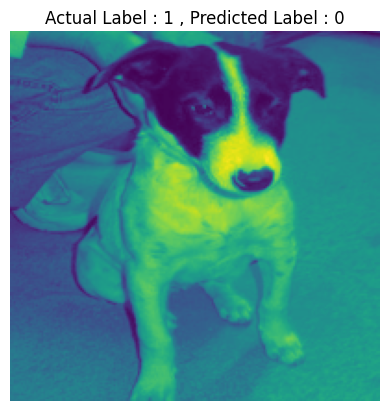

In [48]:
plt.imshow(error_image.reshape(200,200))
plt.title(f"Actual Label : {actual_label} , Predicted Label : {predicted_label}")
plt.axis("off")
plt.show()

In [35]:
predicted_labels

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0])

In [31]:
error_labels

array([1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1])

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0])